<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion2_Prog_DS/blob/main/01_an%C3%A1lisis_exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis exploratorio del dataset Dry_Bean

## Importaciones necesarias

In [4]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

## Carga y lectura de datos

In [5]:
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Raw/Dry_Bean_Dataset.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Información general del dataset

In [6]:
print(f"\n Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

print("\n Tipos de datos:")
display(pd.DataFrame(df.dtypes).reset_index().rename(columns={'index': 'Columna', 0: 'Tipo'}))

print("\n  Valores nulos por columna:")
nulos = df.isnull().sum()
display(pd.DataFrame({'Columna': nulos.index, 'Valores nulos': nulos.values}))


 Dimensiones: 13611 filas x 17 columnas

 Tipos de datos:


,Columna,Tipo
0,Area,int64
1,Perimeter,float64
2,MajorAxisLength,float64
3,MinorAxisLength,float64
4,AspectRation,float64
5,Eccentricity,float64
6,ConvexArea,int64
7,EquivDiameter,float64
8,Extent,float64
9,Solidity,float64



  Valores nulos por columna:


,Columna,Valores nulos
0,Area,0
1,Perimeter,0
2,MajorAxisLength,0
3,MinorAxisLength,0
4,AspectRation,0
5,Eccentricity,0
6,ConvexArea,0
7,EquivDiameter,0
8,Extent,0
9,Solidity,0


## Estadísticas descriptivas

In [7]:
display(df.describe().round(4))

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


## Distribución de clases

In [8]:
conteo = df['Class'].value_counts()
porcentaje = df['Class'].value_counts(normalize=True) * 100

dist_clases = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje': porcentaje.round(2)
})
display(dist_clases)

,Conteo,Porcentaje
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


## Gráfico de barras: distribución de clases

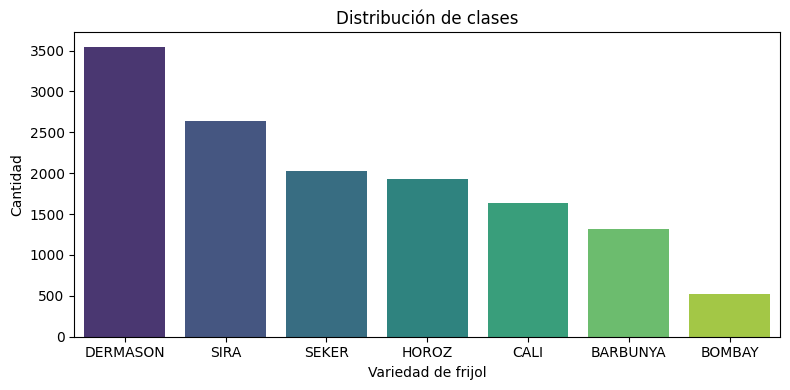

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Class', order=conteo.index, palette='viridis')
plt.title('Distribución de clases')
plt.xlabel('Variedad de frijol')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Distribución de variables numéricas

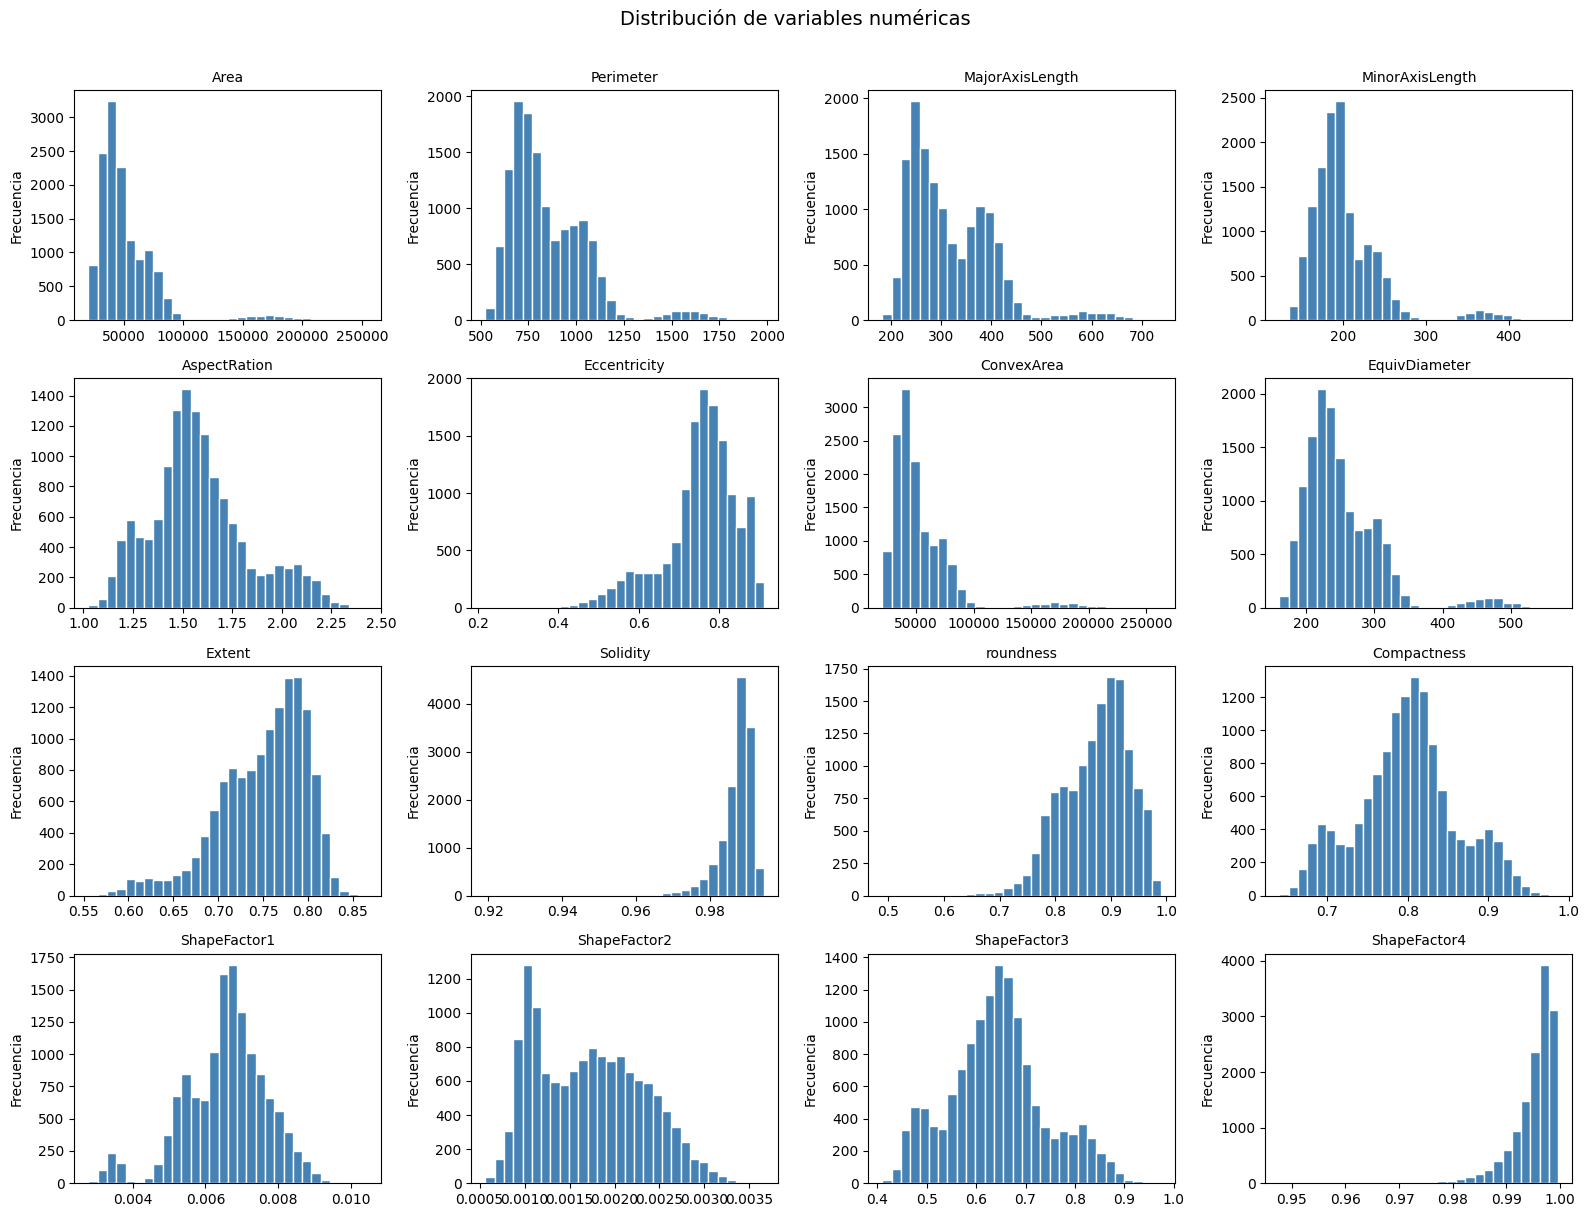

In [10]:
columnas_numericas = df.drop('Class', axis=1).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Comparación de variables relevantes entre variedades de frijol

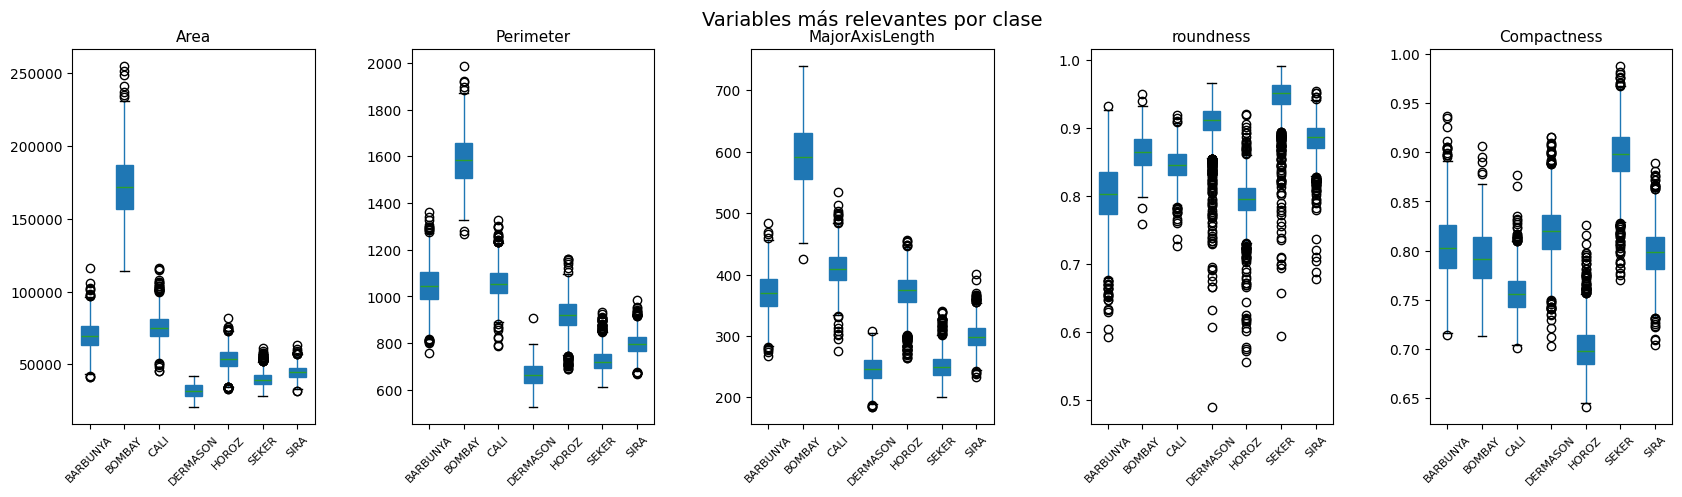

In [11]:
variables_clave = ['Area', 'Perimeter', 'MajorAxisLength', 'roundness', 'Compactness']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(variables_clave):
    df.boxplot(column=col, by='Class', ax=axes[i],
               grid=False, patch_artist=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(),
                             rotation=45, fontsize=8)

plt.suptitle('Variables más relevantes por clase', fontsize=14)
plt.subplots_adjust(wspace=0.4)
plt.show()

## Matriz de correlación entre variables numéricas

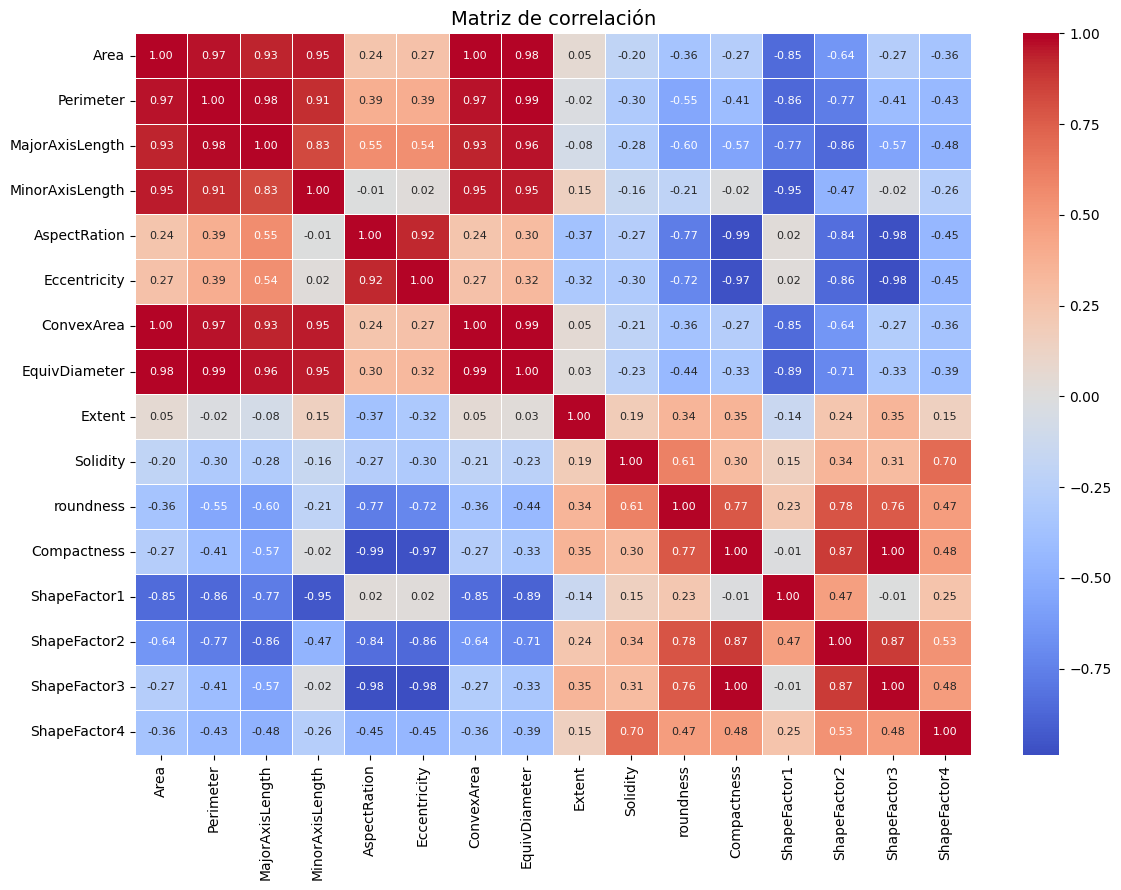

In [12]:
plt.figure(figsize=(12, 9))
corr = df.drop('Class', axis=1).corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})

plt.title('Matriz de correlación', fontsize=14)
plt.tight_layout()
plt.show()

## PCA: reducción de dimensionalidad y visualización

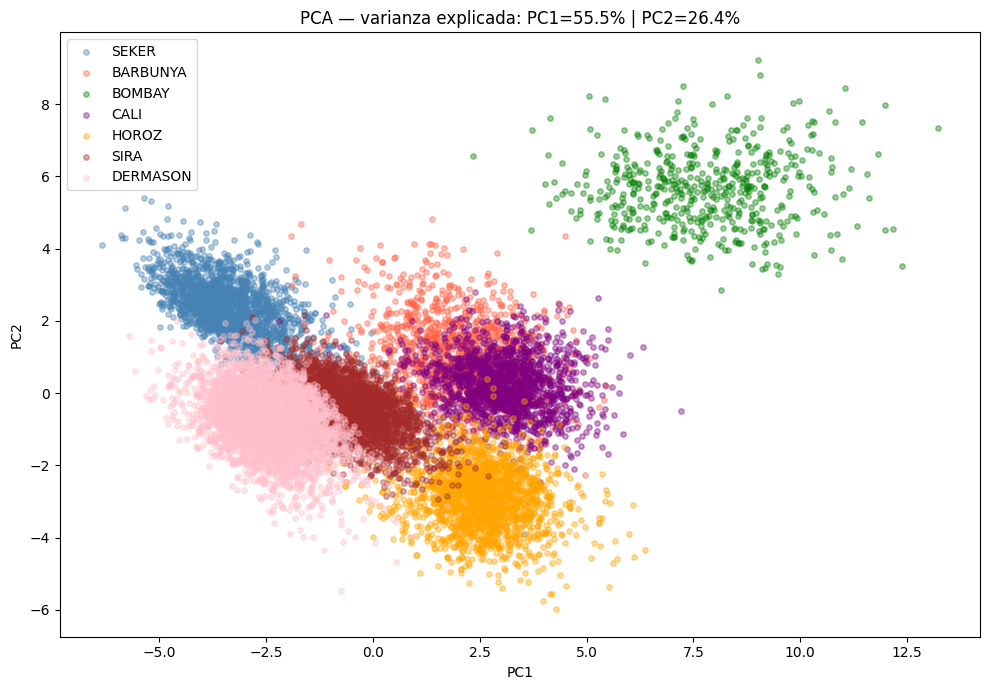

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_eda = StandardScaler()
X_eda = df.drop('Class', axis=1)
X_scaled_eda = scaler_eda.fit_transform(X_eda)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_eda)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class'].values

plt.figure(figsize=(10, 7))
colores = ['steelblue', 'tomato', 'green', 'purple', 'orange', 'brown', 'pink']
clases = df['Class'].unique()

for i, clase in enumerate(clases):
    subset = pca_df[pca_df['Class'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=clase, alpha=0.4, s=15, color=colores[i])

plt.title(f'PCA — varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}% | PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()